In [7]:
path = r"E:\FILES\archive\CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone\CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

In [8]:
import torchvision
from torchvision import datasets, transforms

# Define your transformations
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Point to the directory that CONTAINS the class folders
image_dataset = datasets.ImageFolder(root=path, transform=data_transforms)

print(f"Detected classes: {image_dataset.classes}")
print(f"Total images found: {len(image_dataset)}")

Detected classes: ['Cyst', 'Normal', 'Stone', 'Tumor']
Total images found: 12446


In [9]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. Define your path (ensure this cell ran successfully!)
data_dir = r'E:\FILES\archive\CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone\CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'

# 2. Define transforms (Data Augmentation for Train, simple Resize for Test)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Load the full dataset
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# 4. Calculate split sizes (e.g., 80% Train, 20% Test)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

# 5. Perform the split
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# 6. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training images: {len(train_dataset)}")
print(f"Testing images: {len(test_dataset)}")

Training images: 9956
Testing images: 2490


In [10]:
import torch.nn as nn
from torchvision import models

# Load a pre-trained ResNet18
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze the earlier layers (helps training speed)
for param in model.parameters():
    param.requires_grad = False

# Replace the last fully connected layer (fc)
# model.fc.in_features is 512 for ResNet18
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4) # 4 is the number of your kidney classes

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model is ready on: {device}")

Model is ready on: cpu


In [11]:
import torch.optim as optim

# CrossEntropyLoss is standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Only optimize the parameters of the final layer we just created
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [10]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train() # Set to training mode
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # 1. Zero the parameter gradients
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # 3. Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f'Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f}')

print("Training Complete!")

Epoch 1/10 | Loss: 0.7346
Epoch 2/10 | Loss: 0.4651
Epoch 3/10 | Loss: 0.3747
Epoch 4/10 | Loss: 0.3387
Epoch 5/10 | Loss: 0.2965
Epoch 6/10 | Loss: 0.2699
Epoch 7/10 | Loss: 0.2489
Epoch 8/10 | Loss: 0.2347
Epoch 9/10 | Loss: 0.2239
Epoch 10/10 | Loss: 0.2111
Training Complete!


In [11]:
model.eval() # Set to evaluation mode
correct = 0
total = 0

with torch.no_grad(): # No need to track gradients for testing
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on test images: {100 * correct / total:.2f}%')

Accuracy on test images: 96.35%


Prediction: Stone


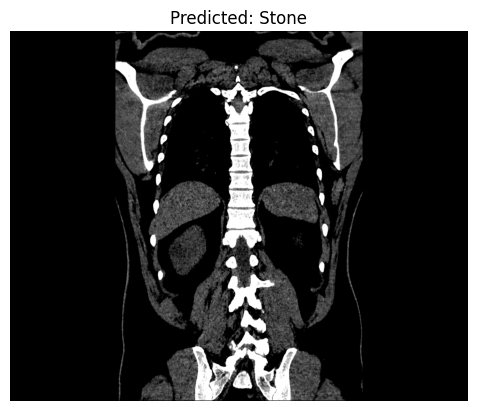

In [ ]:
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_kidney_scan(image_path, model, device):
    # 1. Load the image and convert to RGB
    img = Image.open(image_path).convert('RGB')
    
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    img_tensor = test_transform(img).unsqueeze(0).to(device) # Add batch dimension

    # 3. Predict
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    # 4. Map index to Class Name
    class_name = full_dataset.classes[predicted.item()]
    
    print(f"Prediction: {class_name}")

    # Optional: Display the image
    plt.imshow(img)
    plt.title(f"Predicted: {class_name}")
    plt.axis('off')
    plt.show()

# Replace with a path to an image you want to test
user_image_path = r'E:\FILES\archive\CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone\CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone\Cyst\Cyst- (31).jpg'
predict_kidney_scan(user_image_path, model, device)